# KNN Classification

## Import Libraries

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Load Iris Dataset

In [ ]:

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Train Test Split

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Feature Scaling

In [ ]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Train KNN Model

In [ ]:

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train_scaled, y_train)


KNeighborsClassifier()

## Prediction and Accuracy

In [ ]:

pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.9333333333333333


## Confusion Matrix

In [ ]:

print(confusion_matrix(y_test, pred))


[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


## Classification Report

In [ ]:

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.83      1.00      0.91        10
           2       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## K Value Selection

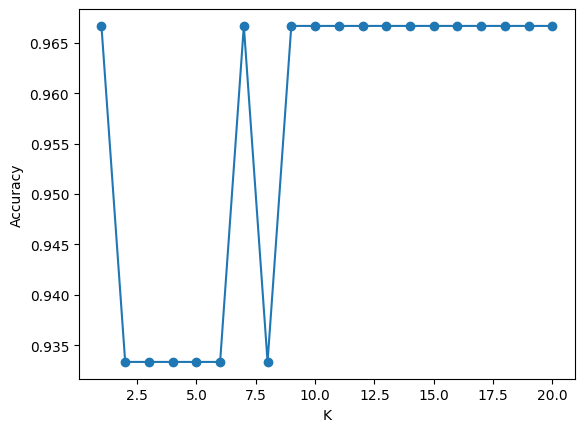

In [ ]:

k_values = range(1,21)
accs = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accs.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

plt.plot(list(k_values), accs, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()


## Hyperparameter Tuning with GridSearchCV

In [ ]:

param_grid = {
    'n_neighbors':[3,5,7,9,11],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)


{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
0.9666666666666668


## Predict New Flower

In [ ]:

sample = [[5.1, 3.5, 1.4, 0.2]]
sample_scaled = scaler.transform(sample)

prediction = grid.best_estimator_.predict(sample_scaled)

print("Predicted Class:", iris.target_names[prediction[0]])


Predicted Class: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Summary

KNN uses distances, therefore feature scaling is critical. We also selected the best K and tuned the model using GridSearchCV.

## For more reference

**Note:** Watch in the following order

1. Gate Smashers: https://youtu.be/O1nWXTXcCwI
2. 5 Minutes Engineering: https://youtu.be/CJjSPCslxqQ
3. Krish Naik: https://youtu.be/gU6KTNbk0hk
4. CampusX: https://youtu.be/abnL_GUGub4